In [5]:
import pickle as pkl
from scipy.special import softmax
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from vla_calibration.utils import *
from vla_calibration.calibration import *

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [6]:
def get_base_data_molmo(data_save_dir, top_n_steps=1):

    with open(f"{data_save_dir}/episode_data_true_prompt.pkl", "rb") as f:  # "rb" = read binary mode
        data = pkl.load(f)

    all_probs = []
    correct = []

    for episode in data:

        steps = episode["steps"]

        episode_probs = []

        for step in steps[:top_n_steps]:

            if ("molmo" not in data_save_dir) and ("nora" not in data_save_dir):


                logits = step["logits"]

                probs = softmax(logits, -1)

            else:
                probs = step["probs"]

            if "nora" in data_save_dir:
                probs = np.mean(probs)

            episode_probs.append(probs)

        episode_probs = np.stack(episode_probs)

        all_probs.append(episode_probs)

        correct.append(int(episode["done"]))

    all_probs = np.stack(all_probs)
    correct = np.array(correct)

    return all_probs, _, correct


In [7]:
def get_base_data_nora(data_save_dir, top_n_steps=1):

    with open(f"{data_save_dir}/episode_data_true_prompt.pkl", "rb") as f:  # "rb" = read binary mode
        data = pkl.load(f)

    all_probs = []
    correct = []

    for episode in data:

        steps = episode["steps"]

        episode_probs = []

        for step in steps[:top_n_steps]:

            if ("molmo" not in data_save_dir) and ("nora" not in data_save_dir):


                logits = step["logits"]

                probs = softmax(logits, -1)

            else:
                probs = step["probs"]

            if "nora" in data_save_dir:
                probs = np.mean(probs)

            episode_probs.append(probs)

        episode_probs = np.stack(episode_probs)

        all_probs.append(episode_probs)

        correct.append(int(episode["done"]))

    all_probs = np.stack(all_probs)
    correct = np.array(correct)

    return all_probs, _, correct


In [ ]:
import numpy as np
import pandas as pd
from scipy.special import softmax

def run_experiment(
    task_name,
    model_name,
    quant=None,
    alternate_set=1,
    n_prompts=20,
    n_cal_bins=12,
    model_type="auto",  # "auto" | "default" | "nora" | "molmo"
):
    """
    Unifies:
      - run_experiment (default logits path)
      - run_experiment_nora (probs + mean over probs)
      - run_experiment_molmo (probs; base averages over last axis; ensemble averages over prompts and last axis)
    Outputs exactly the same DF schema/values as the originals (assuming same helper funcs & data).
    """

    data_save_dir = f"../results/{model_name}/libero_{task_name}"
    if quant is not None:
        data_save_dir += f"/{quant}"

    # decide which branch to use
    if model_type == "auto":
        m = model_name.lower()
        d = data_save_dir.lower()
        if "nora" in m or "nora" in d:
            model_type_ = "nora"
        elif "molmo" in m or "molmo" in d:
            model_type_ = "molmo"
        else:
            model_type_ = "default"
    else:
        model_type_ = model_type

    top_n_steps = 1

    # --- load baseline ---
    if model_type_ == "nora":
        base_probs, _, correct = get_base_data_nora(data_save_dir, top_n_steps)

    elif model_type_ == "molmo":
        base_probs, _, correct = get_base_data_molmo(data_save_dir, top_n_steps)
        base_probs = np.mean(base_probs, -1)  # EXACTLY as in run_experiment_molmo

    elif model_type_ == "default":
        base_probs, _, correct = get_base_data(data_save_dir, top_n_steps)
        base_probs = np.expand_dims(base_probs, axis=2)  # EXACTLY as in run_experiment
    else:
        raise ValueError(f"Unknown model_type={model_type_}")

    # --- load prompts ---
    all_probs = []
    for i in range(n_prompts):
        if alternate_set == 1:
            data_save_str = f"{data_save_dir}/episode_data_prompt_{i}.pkl"
        elif alternate_set == 2:
            data_save_str = f"{data_save_dir}/episode_data_prompt_{i}_v2.pkl"
        elif alternate_set == 3:
            data_save_str = f"{data_save_dir}/episode_data_prompt_{i}_v3.pkl"
        else:
            raise ValueError

        with open(data_save_str, "rb") as f:
            data = pkl.load(f)

        prompt_probs = []
        for episode in data:
            episode_probs = []
            steps = episode["steps"]

            for step in steps[:top_n_steps]:
                if model_type_ == "default":
                    logits = step["logits"]
                    probs = softmax(logits, -1)
                    episode_probs.append(probs)

                elif model_type_ == "nora":
                    probs = step["probs"]
                    probs = np.mean(probs)  # EXACTLY as in run_experiment_nora
                    episode_probs.append(probs)

                elif model_type_ == "molmo":
                    probs = step["probs"]
                    episode_probs.append(probs)

            episode_probs = np.stack(episode_probs)
            prompt_probs.append(episode_probs)

        prompt_probs = np.stack(prompt_probs)
        all_probs.append(prompt_probs)

    all_probs = np.stack(all_probs)

    # --- ensemble aggregation + confidence extraction (match originals) ---
    if model_type_ == "nora":
        ens_probs = np.transpose(all_probs, (1, 2, 0))
        ens_probs = np.mean(ens_probs, -1)

        mean_base_conf = base_probs[:, 0]
        mean_ens_conf  = ens_probs[:, 0]

    elif model_type_ == "molmo":
        ens_probs = np.transpose(all_probs, (1, 2, 3, 0))
        ens_probs = np.mean(np.mean(ens_probs, -1), -1)  # EXACTLY as in run_experiment_molmo

        mean_base_conf = base_probs[:, 0]
        mean_ens_conf  = ens_probs[:, 0]

    elif model_type_ == "default":
        ens_probs = np.transpose(all_probs, (1, 2, 0, 3, 4))

        base_probs_ = base_probs[:, 0]
        ens_probs_  = ens_probs[:, 0]

        base_probs_ = np.max(base_probs_, -1)
        ens_probs_  = np.max(ens_probs_, -1)

        base_conf = np.mean(base_probs_, -2)
        ens_conf  = np.mean(ens_probs_,  -2)

        mean_base_conf = np.mean(base_conf, -1)
        mean_ens_conf  = np.mean(ens_conf,  -1)

    # --- metrics (shared) ---
    base_ece1 = round(get_ece(mean_base_conf, correct, n_cal_bins, p=1), 5)
    ens_ece1  = round(get_ece(mean_ens_conf,  correct, n_cal_bins, p=1), 5)

    base_ece2 = round(get_ece(mean_base_conf, correct, n_cal_bins, p=2), 5)
    ens_ece2  = round(get_ece(mean_ens_conf,  correct, n_cal_bins, p=2), 5)

    base_brier = round(np.mean((mean_base_conf - correct) ** 2), 5)
    ens_brier  = round(np.mean((mean_ens_conf  - correct) ** 2), 5)

    base_ce = cross_entropy(correct, mean_base_conf)
    ens_ce  = cross_entropy(correct, mean_ens_conf)

    quant_tag = quant if quant is not None else "Full"

    rows = [
        [task_name, model_name, quant_tag, "baseline", base_ece1, base_ece2, base_brier, base_ce, np.mean(correct)],
        [task_name, model_name, quant_tag, "reprompt", ens_ece1,  ens_ece2,  ens_brier,  ens_ce,  np.mean(correct)],
    ]
    return pd.DataFrame(
        rows,
        columns=["Dataset", "Model", "Quant", "Method", "ECE-1", "ECE-2", "Brier", "NLL", "Accuracy"],
    )



In [9]:
n_bins = 12
alternate_set = 1
full_df = pd.DataFrame()

In [10]:
model_name = "openvla"

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])

df = run_experiment(
    "object", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])

df = run_experiment(
    "goal", 
    model_name,
    alternate_set=alternate_set,  
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])


In [11]:
full_df

,Dataset,Model,Quant,Method,ECE-1,ECE-2,Brier,NLL,Accuracy
0,spatial,openvla,Full,baseline,0.08794,0.10620,0.14981,0.533038,0.828
1,spatial,openvla,Full,reprompt,0.05246,0.06847,0.14485,0.476606,0.828
0,object,openvla,Full,baseline,0.06018,0.07267,0.10762,0.401004,0.880
1,object,openvla,Full,reprompt,0.03632,0.05273,0.10460,0.360989,0.880
0,goal,openvla,Full,baseline,0.15130,0.17005,0.20654,0.707188,0.758
1,goal,openvla,Full,reprompt,0.11547,0.13220,0.19743,0.619534,0.758


In [12]:
model_name = "nora_long"

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])

model_name = "univla"

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])

model_name = "molmo"

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    n_prompts=20
)
full_df = pd.concat([full_df, df])

In [13]:
full_df

,Dataset,Model,Quant,Method,ECE-1,ECE-2,Brier,NLL,Accuracy
0,spatial,openvla,Full,baseline,0.08794,0.10620,0.14981,0.533038,0.828
1,spatial,openvla,Full,reprompt,0.05246,0.06847,0.14485,0.476606,0.828
0,object,openvla,Full,baseline,0.06018,0.07267,0.10762,0.401004,0.880
1,object,openvla,Full,reprompt,0.03632,0.05273,0.10460,0.360989,0.880
0,goal,openvla,Full,baseline,0.15130,0.17005,0.20654,0.707188,0.758
1,goal,openvla,Full,reprompt,0.11547,0.13220,0.19743,0.619534,0.758
0,spatial,nora_long,Full,baseline,0.09862,0.11526,0.10541,0.385940,0.894
1,spatial,nora_long,Full,reprompt,0.09182,0.11171,0.10458,0.375826,0.894
0,spatial,univla,Full,baseline,0.16178,0.19332,0.06435,0.282146,0.972
1,spatial,univla,Full,reprompt,0.15725,0.19241,0.06382,0.262444,0.972


In [30]:

def plot_pct_change_grid_all(
    df: pd.DataFrame,
    metrics=("ECE-1", "ECE-2", "Brier", "NLL"),
    pal=None,
    openvla_name="OpenVLA",
    spatial_name="Spatial",
    quant_filter=None,  # e.g. "Full" or None
    figsize=(12, 7),
    model_order=("univla", "nora_long", "molmo"),
    savefig=False,
):
    """
    2x2 grid:
      Top row: openVLA across task suites (Dataset) for metrics[0], metrics[1]
      Bottom row: other models on spatial suite for metrics[0], metrics[1]
    Each bar = % change vs baseline: 100*(reprompt-baseline)/baseline (negative = reduction)
    Colors:
      - Top row (openVLA): pal[0]
      - Bottom row (other models): cycle pal[1:3] across models
    """
    if pal is None:
        pal = ["C0", "C1", "C2", "C3"]
    if len(pal) < 3:
        raise ValueError("pal must have at least 3 colors (need pal[0] and pal[1:3]).")

    req_cols = {"Dataset", "Model", "Method", *metrics}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df_plot = df.copy()
    df_plot["Model_l"] = df_plot["Model"].astype(str).str.lower()
    df_plot["Dataset_l"] = df_plot["Dataset"].astype(str).str.lower()
    df_plot["Method_l"] = df_plot["Method"].astype(str).str.lower()

    if quant_filter is not None:
        if "Quant" not in df_plot.columns:
            raise ValueError("quant_filter was set but df has no 'Quant' column.")
        df_plot = df_plot[df_plot["Quant"].astype(str).str.lower().eq(str(quant_filter).lower())].copy()

    def pct_change(reprompt, baseline):
        baseline = np.asarray(baseline, dtype=float)
        reprompt = np.asarray(reprompt, dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            out = 100.0 * (reprompt - baseline) / baseline
        return out

    def make_wide(sub_df, index_col):
        # mean in case duplicates exist
        wide = (
            sub_df.pivot_table(index=index_col, columns="Method_l", values=list(metrics), aggfunc="mean")
            .sort_index()
        )
        # ensure required methods exist
        for m in metrics:
            if (m, "baseline") not in wide.columns or (m, "reprompt") not in wide.columns:
                raise ValueError(f"Need both baseline and reprompt rows for metric '{m}' in {index_col} group.")
        return wide
    

    names_map = {
        "univla": "UniVLA",
        "nora_long": "NORA",
        "molmo": "MolmoAct"
    }

    def bar_pct(ax, labels, values, title, color=None, colors=None, ylabel="% change"):
        x = np.arange(len(labels))
        if colors is not None:
            ax.bar(x, values, color=colors)
        else:
            ax.bar(x, values, color=color)
        ax.set_xticks(x)

        tick_labels = []
        for label in labels:
            if label in names_map:
                tick_label = names_map[label]
            else:
                tick_label = label.replace("_"," ").title()
            tick_labels.append(tick_label)

        ax.set_xticklabels(tick_labels)
        ax.tick_params(axis="x", labelsize=14, rotation=30)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontsize=16)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.grid(axis="y", alpha=0.3)

    # ---- Top row: openVLA across datasets ----
    df_openvla = df_plot[df_plot["Model_l"].eq(openvla_name.lower())].copy()
    openvla_wide = make_wide(df_openvla, "Dataset")
    datasets = openvla_wide.index.tolist()

    top_vals = []
    for m in metrics:
        top_vals.append(pct_change(openvla_wide[(m, "reprompt")], openvla_wide[(m, "baseline")]))

    # ---- Bottom row: other models on spatial ----
    df_spatial_other = df_plot[
        df_plot["Dataset_l"].eq(spatial_name.lower()) & ~df_plot["Model_l"].eq(openvla_name.lower())
    ].copy()
    spatial_wide = make_wide(df_spatial_other, "Model")
    # ---- Apply custom ordering for bottom-row models ----
    if model_order is not None:
        desired = [m.lower() for m in model_order]
        present = [m for m in desired if m in spatial_wide.index.astype(str).str.lower().tolist()]

        # Make an index that matches the *actual* index values (case-sensitive) but ordered by lowercased keys
        idx_lower = spatial_wide.index.astype(str).str.lower()
        ordered_index = []
        for key in present:
            ordered_index.extend(spatial_wide.index[idx_lower == key].tolist())

        missing = [m for m in desired if m not in set(idx_lower)]
        if missing:
            raise ValueError(f"model_order contains models not present in df for Spatial: {missing}. "
                             f"Present: {spatial_wide.index.tolist()}")

        spatial_wide = spatial_wide.loc[ordered_index]

    models = spatial_wide.index.tolist()

    bottom_vals = []
    for m in metrics:
        bottom_vals.append(pct_change(spatial_wide[(m, "reprompt")], spatial_wide[(m, "baseline")]))

    # Colors for bottom row: per-model, cycle pal[1:3]
    bottom_colors = [pal[1 + (i)] for i in range(len(models))]  # uses pal[1], pal[2]
    # If you truly want to use pal[1:3] (two colors) it's pal[1], pal[2]; if you meant 3 colors, pass a longer slice.

    fig, axes = plt.subplots(2, 4, figsize=figsize, constrained_layout=True)

    bar_pct(
        axes[0, 0],
        datasets,
        top_vals[0],
        title=r"$\text{ECE}_1$",
        color=pal[0],
    )
    bar_pct(
        axes[0, 1],
        datasets,
        top_vals[1],
        title=r"$\text{ECE}_2$",
        color=pal[0],
    )

    bar_pct(
        axes[0, 2],
        datasets,
        top_vals[2],
        title=f"{metrics[2]} score",
        color=pal[0],
    )
    bar_pct(
        axes[0, 3],
        datasets,
        top_vals[3],
        title=f"{metrics[3]}",
        color=pal[0],
    )

    bar_pct(
        axes[1, 0],
        models,
        bottom_vals[0],
        title=r"$\text{ECE}_1$",
        colors=bottom_colors,
    )

    bar_pct(
        axes[1, 1],
        models,
        bottom_vals[1],
        title=r"$\text{ECE}_2$",
        colors=bottom_colors,
    )

    bar_pct(
        axes[1, 2],
        models,
        bottom_vals[2],
        title=f"{metrics[2]} score",
        colors=bottom_colors,
    )

    bar_pct(
        axes[1, 3],
        models,
        bottom_vals[3],
        title=f"{metrics[3]}",
        colors=bottom_colors,
    )

    # axes[0,0].set_ylabel("% change", fontsize=14)
    # axes[1,0].set_ylabel("% change", fontsize=14)

    # ---- Titles / layout (prefer constrained_layout; don't also tight_layout) ----
    # fig.suptitle("Impact of Reprompt vs. Baseline Calibration Error", fontsize=20, y=1.10)

    # Add a bit more vertical breathing room for titles + row labels
    fig.set_constrained_layout_pads(h_pad=0.13, w_pad=0.04, hspace=0.13, wspace=0.08)

    fig.canvas.draw()  # finalize positions after pads/suptitle

    # y positions: one ABOVE top row titles, one BETWEEN the rows (above bottom row titles)
    top_row_top = max(ax.get_position().y1 for ax in axes[0, :])
    bottom_row_top = max(ax.get_position().y1 for ax in axes[1, :])
    top_row_bottom = min(ax.get_position().y0 for ax in axes[0, :])

    y_top_label = top_row_top + 0.065
    y_bottom_label = bottom_row_top + 0.065

    fig.text(0.5, y_top_label, "OpenVLA across task suites",
             ha="center", va="bottom", fontsize=18, fontweight="bold")
    fig.text(0.5, y_bottom_label, "Other models on LIBERO Spatial",
             ha="center", va="bottom", fontsize=18, fontweight="bold")


    metrics_str = f"{metrics[0]}_{metrics[1]}"
    if savefig:
        plt.savefig(f"../plots/all_4_models.png", dpi=600, bbox_inches="tight")

    plt.show()

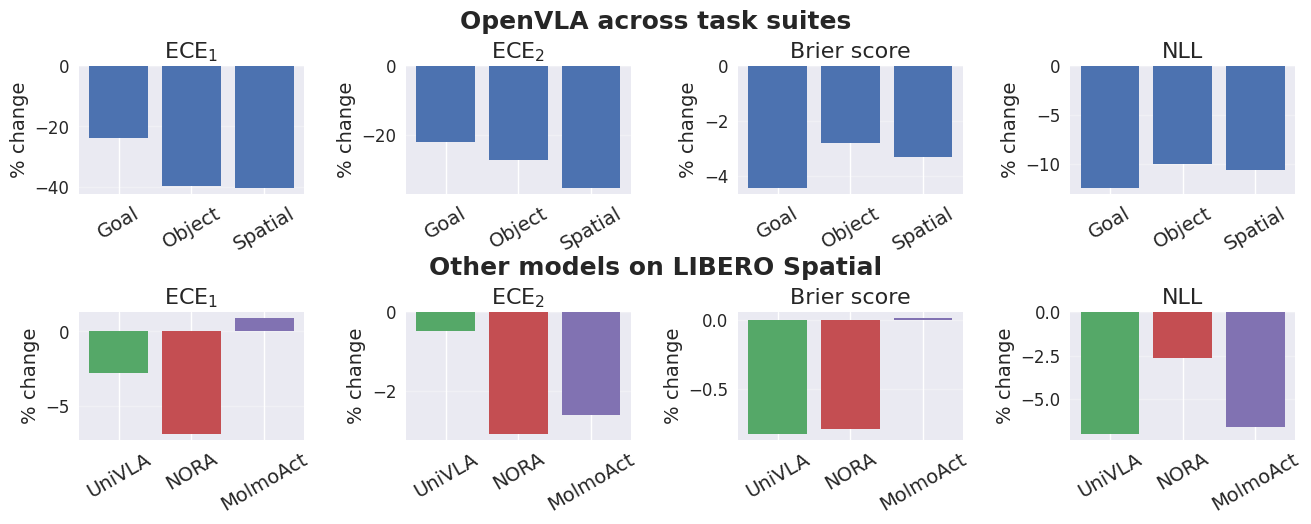

In [32]:
plot_pct_change_grid_all(
    full_df, 
    pal=pal,
    figsize=(13,5),
    savefig=True
)

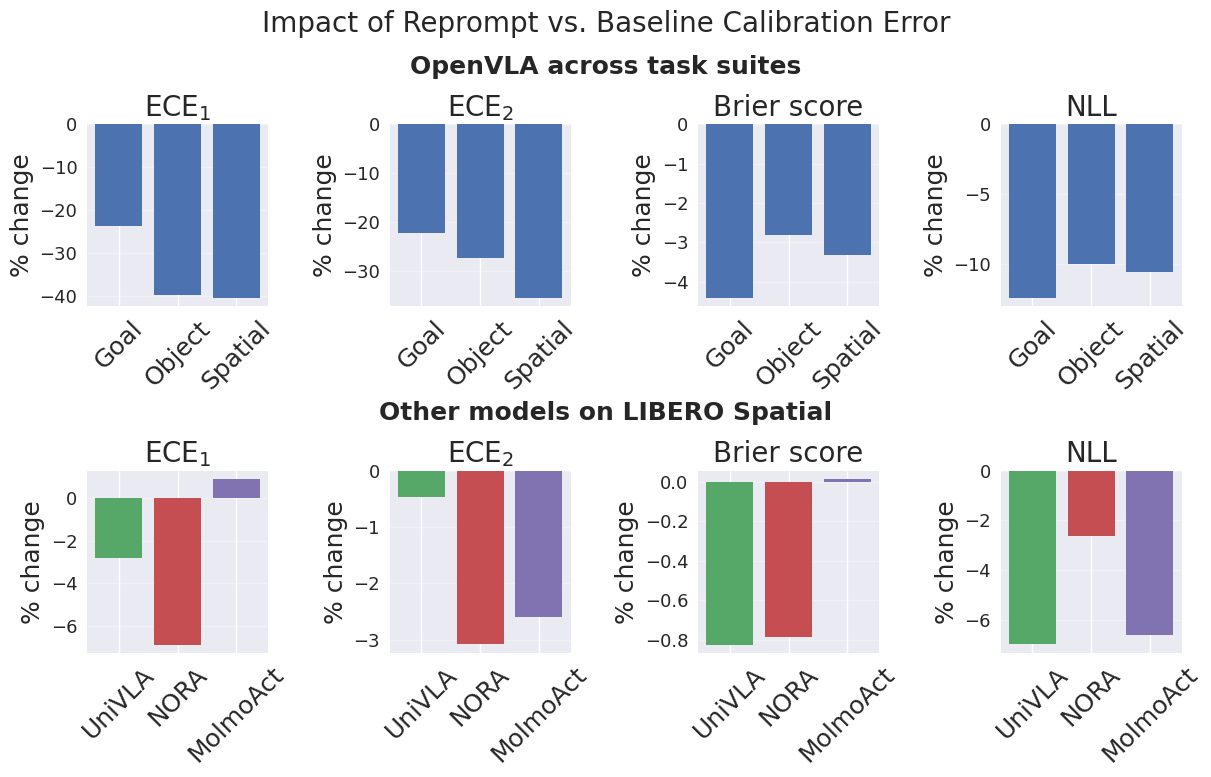

In [16]:
plot_pct_change_grid_all(
    full_df, 
    pal=pal
)

In [94]:
model_names_map = {
    "openvla": "OpenVLA",
    "molmo": "MolmoAct",
    "nora_long": "NORA",
    "univla": "UniVLA"
}

In [100]:
quant_df = pd.DataFrame()

model_name = "openvla"

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant8",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

df = run_experiment(
    "object", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant8",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

df = run_experiment(
    "goal", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant8",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

df = run_experiment(
    "spatial", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant4",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

df = run_experiment(
    "object", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant4",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

df = run_experiment(
    "goal", 
    model_name,
    alternate_set=alternate_set, 
    n_cal_bins=n_bins,
    quant="quant4",
    n_prompts=20
)
quant_df = pd.concat([quant_df, df])

quant_df["Model"] = quant_df["Model"].map(model_names_map)
quant_df["Dataset"] = quant_df["Dataset"].astype(str).str.title()
quant_df["Method"] = quant_df["Method"].astype(str).str.title()

In [101]:
quant_df

,Dataset,Model,Quant,Method,ECE-1,ECE-2,Brier,NLL,Accuracy
0,Spatial,OpenVLA,quant8,Baseline,0.07041,0.09339,0.13781,0.487558,0.844
1,Spatial,OpenVLA,quant8,Reprompt,0.04981,0.06155,0.13113,0.434179,0.844
0,Object,OpenVLA,quant8,Baseline,0.05739,0.06514,0.10957,0.408945,0.876
1,Object,OpenVLA,quant8,Reprompt,0.04143,0.05217,0.10810,0.374542,0.876
0,Goal,OpenVLA,quant8,Baseline,0.13958,0.16273,0.20520,0.713381,0.760
1,Goal,OpenVLA,quant8,Reprompt,0.11696,0.15201,0.19385,0.608067,0.760
0,Spatial,OpenVLA,quant4,Baseline,0.06726,0.08613,0.14929,0.502941,0.822
1,Spatial,OpenVLA,quant4,Reprompt,0.05458,0.07902,0.14817,0.482491,0.822
0,Object,OpenVLA,quant4,Baseline,0.09109,0.11249,0.13540,0.488945,0.850
1,Object,OpenVLA,quant4,Reprompt,0.06625,0.09418,0.13176,0.454047,0.850


In [102]:
non_quant_df = full_df.copy()
non_quant_df["Model"] = non_quant_df["Model"].map(model_names_map)
non_quant_df["Dataset"] = non_quant_df["Dataset"].astype(str).str.title()
non_quant_df["Method"] = non_quant_df["Method"].astype(str).str.title()
non_quant_df

,Dataset,Model,Quant,Method,ECE-1,ECE-2,Brier,NLL,Accuracy
0,Spatial,OpenVLA,Full,Baseline,0.08794,0.10620,0.14981,0.533038,0.828
1,Spatial,OpenVLA,Full,Reprompt,0.05246,0.06847,0.14485,0.476606,0.828
0,Object,OpenVLA,Full,Baseline,0.06018,0.07267,0.10762,0.401004,0.880
1,Object,OpenVLA,Full,Reprompt,0.03632,0.05273,0.10460,0.360989,0.880
0,Goal,OpenVLA,Full,Baseline,0.15130,0.17005,0.20654,0.707188,0.758
1,Goal,OpenVLA,Full,Reprompt,0.11547,0.13220,0.19743,0.619534,0.758
0,Spatial,NORA,Full,Baseline,0.09862,0.11526,0.10541,0.385940,0.894
1,Spatial,NORA,Full,Reprompt,0.09182,0.11171,0.10458,0.375826,0.894
0,Spatial,UniVLA,Full,Baseline,0.16178,0.19332,0.06435,0.282146,0.972
1,Spatial,UniVLA,Full,Reprompt,0.15725,0.19241,0.06382,0.262444,0.972


In [108]:
print_cols = ['Model', 'Dataset', 'Method', 'ECE-1', 'ECE-2', 'Brier', 'NLL']

print(non_quant_df[print_cols].to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lllrrrr}
\toprule
Model & Dataset & Method & ECE-1 & ECE-2 & Brier & NLL \\
\midrule
OpenVLA & Spatial & Baseline & 0.0879 & 0.1062 & 0.1498 & 0.5330 \\
OpenVLA & Spatial & Reprompt & 0.0525 & 0.0685 & 0.1449 & 0.4766 \\
OpenVLA & Object & Baseline & 0.0602 & 0.0727 & 0.1076 & 0.4010 \\
OpenVLA & Object & Reprompt & 0.0363 & 0.0527 & 0.1046 & 0.3610 \\
OpenVLA & Goal & Baseline & 0.1513 & 0.1701 & 0.2065 & 0.7072 \\
OpenVLA & Goal & Reprompt & 0.1155 & 0.1322 & 0.1974 & 0.6195 \\
NORA & Spatial & Baseline & 0.0986 & 0.1153 & 0.1054 & 0.3859 \\
NORA & Spatial & Reprompt & 0.0918 & 0.1117 & 0.1046 & 0.3758 \\
UniVLA & Spatial & Baseline & 0.1618 & 0.1933 & 0.0644 & 0.2821 \\
UniVLA & Spatial & Reprompt & 0.1573 & 0.1924 & 0.0638 & 0.2624 \\
MolmoAct & Spatial & Baseline & 0.1126 & 0.1231 & 0.1337 & 0.6248 \\
MolmoAct & Spatial & Reprompt & 0.1137 & 0.1199 & 0.1338 & 0.5834 \\
\bottomrule
\end{tabular}



In [107]:
print(quant_df[print_cols].to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lllrrrr}
\toprule
Model & Dataset & Method & ECE-1 & ECE-2 & Brier & NLL \\
\midrule
OpenVLA & Spatial & Baseline & 0.0704 & 0.0934 & 0.1378 & 0.4876 \\
OpenVLA & Spatial & Reprompt & 0.0498 & 0.0616 & 0.1311 & 0.4342 \\
OpenVLA & Object & Baseline & 0.0574 & 0.0651 & 0.1096 & 0.4089 \\
OpenVLA & Object & Reprompt & 0.0414 & 0.0522 & 0.1081 & 0.3745 \\
OpenVLA & Goal & Baseline & 0.1396 & 0.1627 & 0.2052 & 0.7134 \\
OpenVLA & Goal & Reprompt & 0.1170 & 0.1520 & 0.1938 & 0.6081 \\
OpenVLA & Spatial & Baseline & 0.0673 & 0.0861 & 0.1493 & 0.5029 \\
OpenVLA & Spatial & Reprompt & 0.0546 & 0.0790 & 0.1482 & 0.4825 \\
OpenVLA & Object & Baseline & 0.0911 & 0.1125 & 0.1354 & 0.4889 \\
OpenVLA & Object & Reprompt & 0.0663 & 0.0942 & 0.1318 & 0.4540 \\
OpenVLA & Goal & Baseline & 0.1615 & 0.1821 & 0.2307 & 0.7475 \\
OpenVLA & Goal & Reprompt & 0.1456 & 0.1535 & 0.2239 & 0.6720 \\
\bottomrule
\end{tabular}

